# Linear Regression Experiments — EQRM vs Baselines

This notebook runs experiments using **only** the base `LinearRegression` modules (no extension).

We compare:
- **ERM** — Empirical Risk Minimization (pools all environments)
- **Oracle** — ERM trained on shuffled effect features (ignores X₂)
- **EQRM** — Quantile Risk Minimization at various α values
- **IRMv1** — Invariant Risk Minimization
- **VREX** — Variance Risk Extrapolation

We use the existing plotting functions from `plotting.py` to visualize:
1. Risk PDFs across environments
2. Risk CDFs across environments
3. Quantile performance curves
4. Regression coefficients (β_cause vs β_effect)
5. QQ-plots

In [1]:
import sys
import os

# Make sure we can import from the LinearRegression directory
LR_DIR = os.path.dirname(os.path.abspath("__file__"))  # notebook dir = LinearRegression/
if LR_DIR not in sys.path:
    sys.path.insert(0, LR_DIR)

import torch
import numpy as np
import math
import matplotlib.pyplot as plt

import datasets
import algorithms
import utils
import plotting

# Robust override to disable LaTeX and use fallback fonts
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "serif"],
    "mathtext.fontset": "dejavuserif"
})
from distributions import *

%matplotlib inline

print(f"PyTorch version: {torch.__version__}")
print(f"Imports successful from: {LR_DIR}")

PyTorch version: 2.11.0+cu130
Imports successful from: /home/samuel/Documents/udem/masters/session2/ift6168/IFT6168/LinearRegression


## 1. Configuration

In [2]:
# ─── Experiment configuration ───────────────────────────────────
SEED = 0
N_ENVS = 50            # number of training environments
N_SAMPLES = 50000       # samples per environment
N_ITERATIONS = 2000     # SGD iterations
DIM_INV = 1             # invariant (causal) feature dimension
DIM_SPU = 1             # spurious (effect) feature dimension
TEST_QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999]

# EQRM alpha values to sweep
ALPHA_VALUES = [0.5, 0.75, 0.9, 0.99]

# Output directory for figures
FIGS_DIR = "figs_notebook/"
os.makedirs(FIGS_DIR, exist_ok=True)

print(f"Config: {N_ENVS} envs, {N_SAMPLES} samples, {N_ITERATIONS} iters")
print(f"EQRM alphas: {ALPHA_VALUES}")

Config: 50 envs, 50000 samples, 2000 iters
EQRM alphas: [0.5, 0.75, 0.9, 0.99]


In [3]:
# Updated model styles for higher contrast and premium look
from matplotlib import colormaps
viridis = colormaps['viridis']

model_styles = {
    "ERM": {"color": "#e31a1c", "linestyle": "--", "marker": "o"}, # Bright Red
    "Oracle": {"color": "#1f78b4", "linestyle": ":", "marker": "s"}, # Midnight Blue
    "IRMv1": {"color": "#33a02c", "linestyle": "-.", "marker": "^"}, # Green
    "VREX": {"color": "#ff7f00", "linestyle": "-.", "marker": "v"}, # Orange
    "EQRM_a=0.5": {"color": viridis(0.1), "linestyle": "-", "marker": "D"},
    "EQRM_a=0.75": {"color": viridis(0.35), "linestyle": "-", "marker": "p"},
    "EQRM_a=0.9": {"color": viridis(0.65), "linestyle": "-", "marker": "*"},
    "EQRM_a=0.99": {"color": viridis(0.95), "linestyle": "-", "marker": "h"},
}

# Override plotting styles in plotting.py using the notebook-defined model_styles
def get_line_colour_and_style_override(model_name, n_settings_per_model=6, clr_iterator=None):
    if model_name in model_styles:
        style = model_styles[model_name]
        return style["color"], style["linestyle"], clr_iterator
    return plotting.get_line_colour_and_style(model_name, n_settings_per_model, clr_iterator)

plotting.get_line_colour_and_style = get_line_colour_and_style_override
print("Model styles updated and plotting override applied.")

Model styles updated and plotting override applied.


## 2. Create the Dataset (Example2 — LogNormal environment distribution)

In [4]:
utils.set_seed(SEED)

dataset = datasets.Example2(
    dim_inv=DIM_INV,
    dim_spu=DIM_SPU,
    n_envs=N_ENVS,
    verbose=True  # print analytical + empirical OLS results
)

print(f"\nDataset has {len(dataset.envs)} environments")
print(f"Environment distribution: {dataset.p_env.__class__.__name__}")
print(f"Env stddevs (first 10): {[f'{v:.2f}' for k, v in list(dataset.envs.items())[:10]]}")

Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75
Empirical OLS results (per env):
Env 0
X1: MSE=2.07; coeff=[[0.9920976]]
X2: MSE=2.29; coeff=[[0.25196928]]
[X1,X2]: MSE=1.70; coeffs=[[0.8084018 ]
 [0.18429597]]
Env 1
X1: MSE=1.97; coeff=[[0.963204]]
X2: MSE=0.55; coeff=[[0.81372136]]
[X1,X2]: MSE=0.50; coeffs=[[0.2531463]
 [0.7461257]]
Env 2
X1: MSE=2.02; coeff=[[0.99546355]]
X2: MSE=0.04; coeff=[[0.98560864]]
[X1,X2]: MSE=0.04; coeffs=[[0.02511489]
 [0.97739375]]
Env 3
X1: MSE=2.02; coeff=[[0.9975247]]
X2: MSE=1.26; coeff=[[0.57331514]]
[X1,X2]: MSE=1.04; coeffs=[[0.5120612 ]
 [0.47568697]]
Env 4
X1: MSE=1.95; coeff=[[1.0091554]]
X2: MSE=0.20; coeff=[[0.9312823]]
[X1,X2]: MSE=0.20; coeffs=[[0.10175037]
 [0.89901483]]
Env 5
X1: MSE=2.01; coeff=[[0.985092]]
X2: MSE=0.13; coeff=[[0.9522123]]
[X1,X2]: MSE=0.13; coeffs=[[0.05762756]
 [0.9339371 ]]
Env 6
X1: MSE=1.96; coeff=[[1.003066]]
X2: MSE=1.12; coeff=[[0.6269087]]
[X1,X2]: MSE=0.93; coeffs=[[0.48065382]
 [0.52464855]]
Env 7
X1: MSE=2.

## 3. Sample Environments

In [5]:
def build_envs(dataset, n_samples, train_split="train"):
    """
    Build the train/validation/test environment data.
    
    For Oracle: train_split='test' shuffles X_2 so the model ignores it.
    """
    envs = {}
    for key_split, split in zip(
        ("train", "validation", "test"),
        (train_split, train_split, "test")
    ):
        envs[key_split] = {"keys": [], "envs": []}
        for env in dataset.envs:
            envs[key_split]["envs"].append(
                dataset.sample(n=n_samples, env=env, split=split)
            )
            envs[key_split]["keys"].append(env)
    return envs


def add_test_quantile_envs(envs, dataset, n_samples, test_quantiles):
    """Add test environments at specific quantiles of the env distribution."""
    quantile_keys = []
    for q in test_quantiles:
        inputs, outputs, sdv = dataset.sample(n=n_samples, env=f"test_q={q}")
        envs["test"]["envs"].append((inputs, outputs))
        key = f"q={q}_s={sdv:.1f}"
        envs["test"]["keys"].append(key)
        quantile_keys.append(key)
    return envs, quantile_keys


# Build envs for regular algorithms
utils.set_seed(SEED)
envs_regular = build_envs(dataset, N_SAMPLES, train_split="train")
envs_regular, q_keys = add_test_quantile_envs(envs_regular, dataset, N_SAMPLES, TEST_QUANTILES)

# Build envs for Oracle (shuffled X_2)
utils.set_seed(SEED)
envs_oracle = build_envs(dataset, N_SAMPLES, train_split="test")
envs_oracle, _ = add_test_quantile_envs(envs_oracle, dataset, N_SAMPLES, TEST_QUANTILES)

print(f"Train envs: {len(envs_regular['train']['envs'])}")
print(f"Test envs (incl. quantiles): {len(envs_regular['test']['envs'])}")
print(f"Quantile test keys: {q_keys}")

Train envs: 50
Test envs (incl. quantiles): 57
Quantile test keys: ['q=0.1_s=0.4', 'q=0.25_s=0.6', 'q=0.5_s=1.0', 'q=0.75_s=1.6', 'q=0.9_s=2.5', 'q=0.99_s=5.2', 'q=0.999_s=8.9']


## 4. Train All Algorithms

In [6]:
def train_algorithm(alg_class, envs, in_features, n_iterations, hparams="default", **kwargs):
    """Instantiate and train an algorithm."""
    alg = alg_class(
        in_features=in_features,
        out_features=1,
        task="regression",
        hparams=hparams,
        **kwargs
    )
    alg.fit(envs=envs, n_iterations=n_iterations, callback=True)
    return alg


in_features = DIM_INV + DIM_SPU
trained_models = {}  # name -> (algorithm, envs_used)

# ─── ERM ─────────────────────────────────────────────────────
print("Training ERM...")
utils.set_seed(SEED + 1000)
erm = train_algorithm(algorithms.ERM, envs_regular, in_features, N_ITERATIONS)
trained_models["ERM"] = (erm, envs_regular)
print(f"  weights: {erm.network.weight.data.tolist()}, bias: {erm.network.bias.data.tolist()}")

# ─── Oracle ───────────────────────────────────────────────────
print("Training Oracle...")
utils.set_seed(SEED + 1000)
oracle = train_algorithm(algorithms.ERM, envs_oracle, in_features, N_ITERATIONS)
trained_models["Oracle"] = (oracle, envs_oracle)
print(f"  weights: {oracle.network.weight.data.tolist()}, bias: {oracle.network.bias.data.tolist()}")

# ─── EQRM (multiple alphas) ──────────────────────────────────
for alpha in ALPHA_VALUES:
    name = f"EQRM_a={alpha}"
    print(f"Training {name}...")
    utils.set_seed(SEED + 1000)
    eqrm = train_algorithm(algorithms.EQRM, envs_regular, in_features, N_ITERATIONS)
    eqrm.hparams["alpha"] = alpha  # override alpha
    # Re-train with the correct alpha
    utils.set_seed(SEED + 1000)
    eqrm = algorithms.EQRM(
        in_features=in_features, out_features=1, task="regression", hparams="default"
    )
    eqrm.hparams["alpha"] = alpha
    eqrm.fit(envs=envs_regular, n_iterations=N_ITERATIONS, callback=True)
    trained_models[name] = (eqrm, envs_regular)
    print(f"  weights: {eqrm.network.weight.data.tolist()}, bias: {eqrm.network.bias.data.tolist()}")

# ─── IRMv1 ────────────────────────────────────────────────────
print("Training IRMv1...")
utils.set_seed(SEED + 1000)
irm = train_algorithm(algorithms.IRMv1, envs_regular, in_features, N_ITERATIONS)
trained_models["IRMv1"] = (irm, envs_regular)
w_irm = irm.network.layer.weight.data.tolist()
b_irm = irm.network.layer.bias.data.tolist()
print(f"  weights: {w_irm}, bias: {b_irm}")

# ─── VREX ─────────────────────────────────────────────────────
print("Training VREX...")
utils.set_seed(SEED + 1000)
vrex = train_algorithm(algorithms.VREX, envs_regular, in_features, N_ITERATIONS)
trained_models["VREX"] = (vrex, envs_regular)
print(f"  weights: {vrex.network.weight.data.tolist()}, bias: {vrex.network.bias.data.tolist()}")

print(f"\n✅ Trained {len(trained_models)} models: {list(trained_models.keys())}")

Training ERM...
  weights: [[0.4733048975467682, 0.5261611938476562]], bias: [-0.00042834741179831326]
Training Oracle...
  weights: [[0.9994958639144897, 0.0007785342750139534]], bias: [0.0021454819943755865]
Training EQRM_a=0.5...
  weights: [[0.3664221167564392, 0.6334896683692932]], bias: [0.0011749729746952653]
Training EQRM_a=0.75...
  weights: [[0.5647498369216919, 0.4355725347995758]], bias: [0.0029965401627123356]
Training EQRM_a=0.9...
  weights: [[0.713333010673523, 0.28623074293136597]], bias: [-0.0004965940024703741]
Training EQRM_a=0.99...
  weights: [[0.8955550193786621, 0.09751398861408234]], bias: [-0.00035613245563581586]
Training IRMv1...
  weights: [[-0.09984257817268372, 0.0363876037299633]], bias: [-0.00018621550407260656]
Training VREX...
  weights: [[0.8428554534912109, 0.09971276670694351]], bias: [0.0039444551803171635]

✅ Trained 8 models: ['ERM', 'Oracle', 'EQRM_a=0.5', 'EQRM_a=0.75', 'EQRM_a=0.9', 'EQRM_a=0.99', 'IRMv1', 'VREX']


## 5. Evaluate and Collect Results

In [7]:
DATASET_NAME = "Example2"

def get_weights(alg, model_name):
    """Extract weight vector from an algorithm (handles IRM wrapper)."""
    if "IRM" in model_name:
        w = alg.network.layer.weight.data.flatten().tolist()
        b = alg.network.layer.bias.data.flatten().tolist()
    else:
        w = alg.network.weight.data.flatten().tolist()
        b = alg.network.bias.data.flatten().tolist()
    return [round(wi, 3) for wi in w], [round(bi, 3) for bi in b]


# ─── table_all_envs: per-model, per-training-env validation errors ────
# Structure: {dataset: {model_name: {env_key: {"mean": ..., "std": ...}}}}
table_all_envs = {DATASET_NAME: {}}

# ─── table_quantiles: per-model, per-quantile test errors ─────────────
table_quantiles = {DATASET_NAME: {}}

# ─── weights_dict: per-model weights ─────────────────────────────────
weights_dict = {DATASET_NAME: {}}

for m_name, (alg, envs_used) in trained_models.items():
    table_all_envs[DATASET_NAME][m_name] = {}
    table_quantiles[DATASET_NAME][m_name] = {}
    
    # Per-training-env validation errors
    for k_env, env in zip(envs_used["validation"]["keys"], envs_used["validation"]["envs"]):
        err = utils.compute_error(alg, *env)
        table_all_envs[DATASET_NAME][m_name][k_env] = {"mean": err, "std": 0.0}
    
    # Per-quantile test errors (from the quantile test envs)
    for k_env, env in zip(envs_used["test"]["keys"], envs_used["test"]["envs"]):
        if "q=" in k_env:
            err = utils.compute_error(alg, *env)
            table_quantiles[DATASET_NAME][m_name][k_env] = {"mean": err, "std": 0.0}
    
    # Weights
    w, b = get_weights(alg, m_name)
    weights_dict[DATASET_NAME][m_name] = {"w": w, "b": b}

print("Models evaluated:")
for m_name in table_all_envs[DATASET_NAME]:
    n_envs_eval = len(table_all_envs[DATASET_NAME][m_name])
    n_q_eval = len(table_quantiles[DATASET_NAME][m_name])
    w, b = weights_dict[DATASET_NAME][m_name]["w"], weights_dict[DATASET_NAME][m_name]["b"]
    
    # Avg risk across training envs
    avg_risk = np.mean([v["mean"] for v in table_all_envs[DATASET_NAME][m_name].values()])
    print(f"  {m_name:20s} | avg_risk={avg_risk:.4f} | w={w} | b={b} | {n_envs_eval} envs, {n_q_eval} quantiles")

Models evaluated:
  ERM                  | avg_risk=0.9462 | w=[0.473, 0.526] | b=[-0.0] | 50 envs, 7 quantiles
  Oracle               | avg_risk=2.0001 | w=[0.999, 0.001] | b=[0.002] | 50 envs, 7 quantiles
  EQRM_a=0.5           | avg_risk=0.9895 | w=[0.366, 0.633] | b=[0.001] | 50 envs, 7 quantiles
  EQRM_a=0.75          | avg_risk=0.9778 | w=[0.565, 0.436] | b=[0.003] | 50 envs, 7 quantiles
  EQRM_a=0.9           | avg_risk=1.1661 | w=[0.713, 0.286] | b=[-0.0] | 50 envs, 7 quantiles
  EQRM_a=0.99          | avg_risk=1.6464 | w=[0.896, 0.098] | b=[-0.0] | 50 envs, 7 quantiles
  IRMv1                | avg_risk=2.9911 | w=[-0.1, 0.036] | b=[-0.0] | 50 envs, 7 quantiles
  VREX                 | avg_risk=1.6425 | w=[0.843, 0.1] | b=[0.004] | 50 envs, 7 quantiles


## 6. Visualizations — Using Existing Plotting Functions

We use the functions from `plotting.py`:
- `plot_risk_pdfs` — Risk density distributions
- `plot_risk_cdfs` — Risk CDFs
- `plot_quantile_performance` — Risk vs. quantile
- `plot_coefficients` — β_cause vs β_effect bar chart
- `qq_plot` — QQ-plot for risk distributions

Plotting risk PDFs...


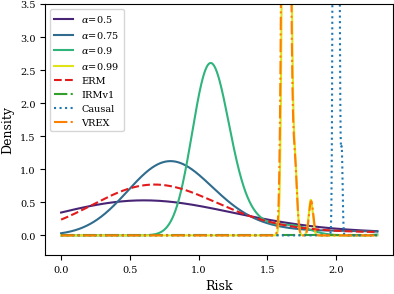

In [8]:
# Ensure LaTeX is disabled before plotting
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "serif"],
    "mathtext.fontset": "dejavuserif"
})

# ─── 6a. Risk PDFs ───────────────────────────────────────────
print("Plotting risk PDFs...")
plotting.plot_risk_pdfs(table_all_envs, savedir=FIGS_DIR, fname="risk_pdfs")
plt.show()

Plotting risk CDFs...


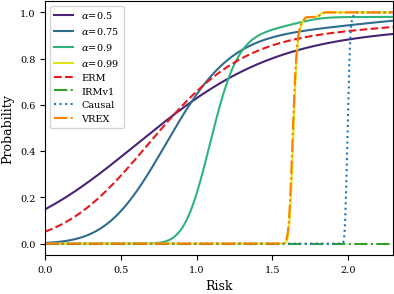

In [9]:
# Ensure LaTeX is disabled before plotting
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "serif"],
    "mathtext.fontset": "dejavuserif"
})

# ─── 6b. Risk CDFs ───────────────────────────────────────────
print("Plotting risk CDFs...")
plotting.plot_risk_cdfs(table_all_envs, savedir=FIGS_DIR, fname="risk_cdfs")
plt.show()

Plotting quantile performance...


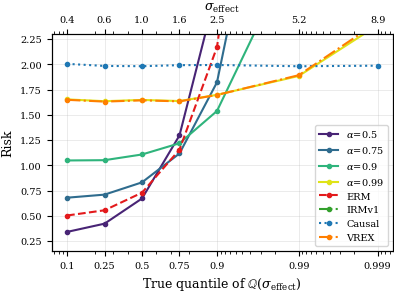

In [10]:
# Ensure LaTeX is disabled before plotting
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "serif"],
    "mathtext.fontset": "dejavuserif"
})

# ─── 6c. Quantile Performance ────────────────────────────────
print("Plotting quantile performance...")
plotting.plot_quantile_performance(table_quantiles, savedir=FIGS_DIR, fname="quantile_perf")
plt.show()

Plotting regression coefficients...


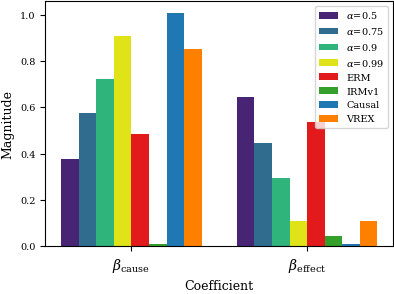

In [11]:
# Ensure LaTeX is disabled before plotting
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "serif"],
    "mathtext.fontset": "dejavuserif"
})

# ─── 6d. Regression Coefficients ─────────────────────────────
print("Plotting regression coefficients...")
plotting.plot_coefficients(weights_dict, savedir=FIGS_DIR, fname="coefficients")
plt.show()

Plotting QQ-plot for EQRM_a=0.99...


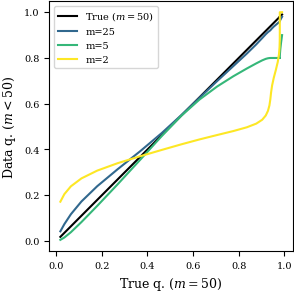

In [12]:
# Ensure LaTeX is disabled before plotting
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "serif"],
    "mathtext.fontset": "dejavuserif"
})

# ─── 6e. QQ-Plot ─────────────────────────────────────────────
# QQ-plot for a specific EQRM model
qq_model = f"EQRM_a={ALPHA_VALUES[-1]}"  # use highest alpha
print(f"Plotting QQ-plot for {qq_model}...")
plotting.qq_plot(table_all_envs, savedir=FIGS_DIR, fname="qq", m_name=qq_model)
plt.show()

## 7. Training Curves (Callback Analysis)

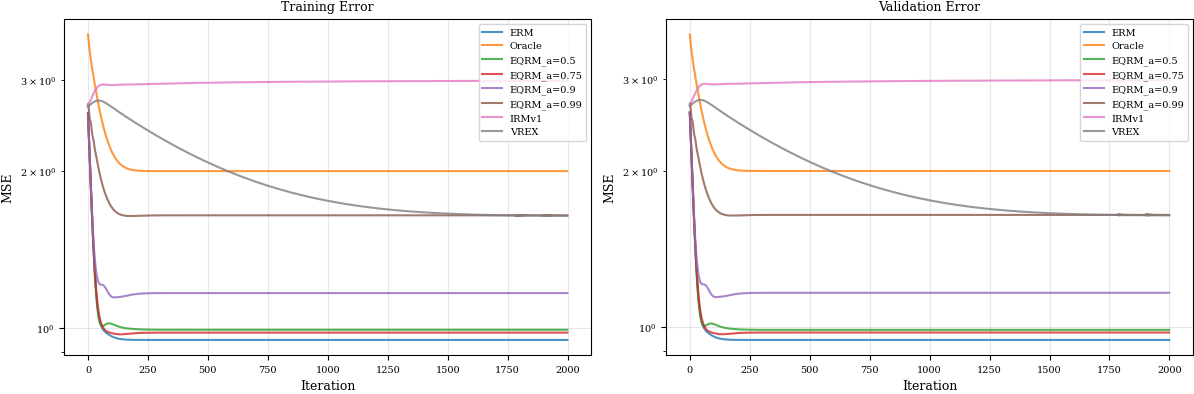

In [13]:
# Plot training error convergence for each model
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for m_name, (alg, _) in trained_models.items():
    # Average training error across environments over iterations
    train_errors = alg.callbacks["errors"]["train"]
    if train_errors:
        # Each env key has a list of errors (one per iteration)
        all_env_errors = list(train_errors.values())
        n_iters = len(all_env_errors[0])
        avg_train = [np.mean([env_errs[i] for env_errs in all_env_errors]) for i in range(n_iters)]
        axes[0].plot(avg_train, label=m_name, alpha=0.8)

    # Average validation error
    val_errors = alg.callbacks["errors"]["validation"]
    if val_errors:
        all_env_errors = list(val_errors.values())
        n_iters = len(all_env_errors[0])
        avg_val = [np.mean([env_errs[i] for env_errs in all_env_errors]) for i in range(n_iters)]
        axes[1].plot(avg_val, label=m_name, alpha=0.8)

axes[0].set_title("Training Error")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE")
axes[0].legend(fontsize=7)
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Validation Error")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("MSE")
axes[1].legend(fontsize=7)
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)

# plt.tight_layout()  # Using constrained layout instead
plt.savefig(os.path.join(FIGS_DIR, "training_curves.pdf"))
plt.show()

## 8. Per-Environment Risk Heatmap

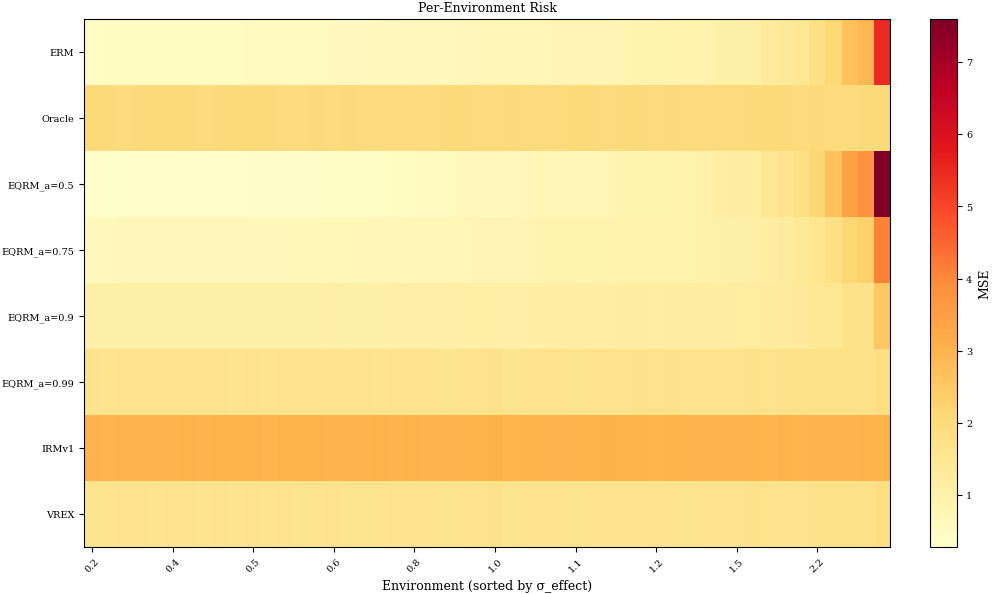


Summary statistics:
         ERM    Oracle   EQRM_a=0.5  EQRM_a=0.75  EQRM_a=0.9  EQRM_a=0.99   IRMv1    VREX  
count  50.0000  50.0000    50.0000     50.0000      50.0000     50.0000    50.0000  50.0000
mean    0.9462   2.0001     0.9895      0.9778       1.1661      1.6464     2.9911   1.6425
std     0.8356   0.0128     1.2125      0.5720       0.2464      0.0305     0.0198   0.0317
min     0.4609   1.9763     0.2862      0.6444       1.0198      1.6096     2.9431   1.6050
25%     0.5295   1.9899     0.3856      0.6938       1.0456      1.6309     2.9752   1.6265
50%     0.7139   1.9994     0.6526      0.8173       1.0958      1.6420     2.9907   1.6366
75%     0.9179   2.0081     0.9484      0.9589       1.1592      1.6539     3.0048   1.6500
max     5.4968   2.0410     7.5914      4.0946       2.5132      1.8159     3.0321   1.8186


In [14]:
import pandas as pd

# Build a DataFrame of per-env risks
risk_data = {}
for m_name in table_all_envs[DATASET_NAME]:
    env_risks = table_all_envs[DATASET_NAME][m_name]
    risk_data[m_name] = {k: v["mean"] for k, v in env_risks.items()}

df_risk = pd.DataFrame(risk_data)

# Sort by environment stddev
env_sdvs = {k: dataset.envs[k] for k in df_risk.index if k in dataset.envs}
sorted_envs = sorted(env_sdvs.keys(), key=lambda k: env_sdvs[k])
df_risk = df_risk.loc[sorted_envs]

# Plot
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
im = ax.imshow(df_risk.values.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(len(df_risk.columns)))
ax.set_yticklabels(df_risk.columns)
ax.set_xlabel("Environment (sorted by σ_effect)")
ax.set_title("Per-Environment Risk")

# Show every 5th env label
tick_positions = list(range(0, len(sorted_envs), max(1, len(sorted_envs) // 10)))
ax.set_xticks(tick_positions)
ax.set_xticklabels([f"{env_sdvs[sorted_envs[i]]:.1f}" for i in tick_positions], rotation=45)

# plt.tight_layout()  # Using constrained layout instead
plt.colorbar(im, ax=ax, label="MSE")
plt.savefig(os.path.join(FIGS_DIR, f"{DATASET_NAME}_risk_heatmap.pdf"))
plt.show()

print("\nSummary statistics:")
print(df_risk.describe().round(4).to_string())

## 9. Experiment: Different Environment Distributions

Compare EQRM behavior when the environment shift distribution (σ_effect) changes.
We use `Example2HN` (HalfNormal), `Example2GB` (Gumbel), `Example2WB` (Weibull), and `Example2EXP` (Exponential).

In [15]:
dist_variants = {
    "LogNormal": datasets.Example2,
    "HalfNormal": datasets.Example2HN,
    "Gumbel": datasets.Example2GB,
    "Weibull": datasets.Example2WB,
    "Exponential": datasets.Example2EXP,
}

dist_results = {}  # dist_name -> {model_name -> {"avg_risk": ..., "w": ..., ...}}
ALPHA_COMPARE = 0.9  # single alpha for comparison

for dist_name, DatasetClass in dist_variants.items():
    print(f"\n{'='*60}")
    print(f"Distribution: {dist_name}")
    print(f"{'='*60}")
    
    utils.set_seed(SEED)
    ds = DatasetClass(dim_inv=DIM_INV, dim_spu=DIM_SPU, n_envs=N_ENVS)
    
    # Build envs
    envs_r = build_envs(ds, N_SAMPLES, "train")
    envs_o = build_envs(ds, N_SAMPLES, "test")
    
    dist_results[dist_name] = {}
    
    # Train ERM
    utils.set_seed(SEED + 1000)
    erm_d = algorithms.ERM(in_features, 1, "regression")
    erm_d.fit(envs_r, N_ITERATIONS)
    
    # Train Oracle
    utils.set_seed(SEED + 1000)
    orc_d = algorithms.ERM(in_features, 1, "regression")
    orc_d.fit(envs_o, N_ITERATIONS)
    
    # Train EQRM
    utils.set_seed(SEED + 1000)
    eqrm_d = algorithms.EQRM(in_features, 1, "regression")
    eqrm_d.hparams["alpha"] = ALPHA_COMPARE
    eqrm_d.fit(envs_r, N_ITERATIONS)
    
    for name, alg, envs_u in [("ERM", erm_d, envs_r), ("Oracle", orc_d, envs_o), (f"EQRM_a={ALPHA_COMPARE}", eqrm_d, envs_r)]:
        risks = [utils.compute_error(alg, *env) for env in envs_u["validation"]["envs"]]
        if "IRM" in name:
            w = alg.network.layer.weight.data.flatten().tolist()
        else:
            w = alg.network.weight.data.flatten().tolist()
        
        dist_results[dist_name][name] = {
            "avg_risk": np.mean(risks),
            "max_risk": np.max(risks),
            "w": [round(wi, 3) for wi in w]
        }
        print(f"  {name:20s} | avg={np.mean(risks):.4f} | max={np.max(risks):.4f} | w={[round(wi, 3) for wi in w]}")


Distribution: LogNormal
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75
  ERM                  | avg=0.9456 | max=5.5174 | w=[0.474, 0.526]
  Oracle               | avg=1.9994 | max=2.0493 | w=[0.999, 0.0]
  EQRM_a=0.9           | avg=1.1663 | max=2.4968 | w=[0.713, 0.285]

Distribution: HalfNormal
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.25
  ERM                  | avg=0.3572 | max=1.7216 | w=[0.178, 0.821]
  Oracle               | avg=1.9994 | max=2.0493 | w=[0.999, 0.0]
  EQRM_a=0.9           | avg=0.4468 | max=1.2499 | w=[0.373, 0.629]

Distribution: Gumbel
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.55
  ERM                  | avg=0.7259 | max=2.9109 | w=[0.363, 0.636]
  Oracle               | avg=2.0002 | max=2.0410 | w=[0.999, -0.0]
  EQRM_a=0.9           | avg=1.0068 | max=1.6209 | w=[0.669, 0.338]

Distribution: Weibull
Analytical OLS results
X1:MSE=1.33;	X2:MSE=1.36
  ERM                  | avg=1.5181 | max=18.5801 | w=[0.762, 0.238]
  Oracle               | avg=1.9994 

In [16]:
# ─── Summary table ───────────────────────────────────────────
import pandas as pd

rows = []
for dist_name, models in dist_results.items():
    for m_name, metrics in models.items():
        rows.append({
            "Distribution": dist_name,
            "Algorithm": m_name,
            "Avg Risk": f"{metrics['avg_risk']:.4f}",
            "Max Risk": f"{metrics['max_risk']:.4f}",
            "β_cause": metrics["w"][0],
            "β_effect": metrics["w"][1] if len(metrics["w"]) > 1 else "N/A"
        })

df_summary = pd.DataFrame(rows)
print("\n" + "="*80)
print("SUMMARY: Across Environment Distributions")
print("="*80)
print(df_summary.to_string(index=False))


SUMMARY: Across Environment Distributions
Distribution Algorithm  Avg Risk Max Risk  β_cause  β_effect
  LogNormal         ERM  0.9456   5.5174   0.474      0.526 
  LogNormal      Oracle  1.9994   2.0493   0.999      0.000 
  LogNormal  EQRM_a=0.9  1.1663   2.4968   0.713      0.285 
 HalfNormal         ERM  0.3572   1.7216   0.178      0.821 
 HalfNormal      Oracle  1.9994   2.0493   0.999      0.000 
 HalfNormal  EQRM_a=0.9  0.4468   1.2499   0.373      0.629 
     Gumbel         ERM  0.7259   2.9109   0.363      0.636 
     Gumbel      Oracle  2.0002   2.0410   0.999     -0.000 
     Gumbel  EQRM_a=0.9  1.0068   1.6209   0.669      0.338 
    Weibull         ERM  1.5181  18.5801   0.762      0.238 
    Weibull      Oracle  1.9994   2.0493   0.999      0.000 
    Weibull  EQRM_a=0.9  1.8075   2.6426   0.936      0.053 
Exponential         ERM  0.3965   5.6702   0.199      0.801 
Exponential      Oracle  1.9994   2.0493   0.999      0.000 
Exponential  EQRM_a=0.9  0.5185   3.2735  

## 10. Visualize: β_cause vs β_effect Across Distributions

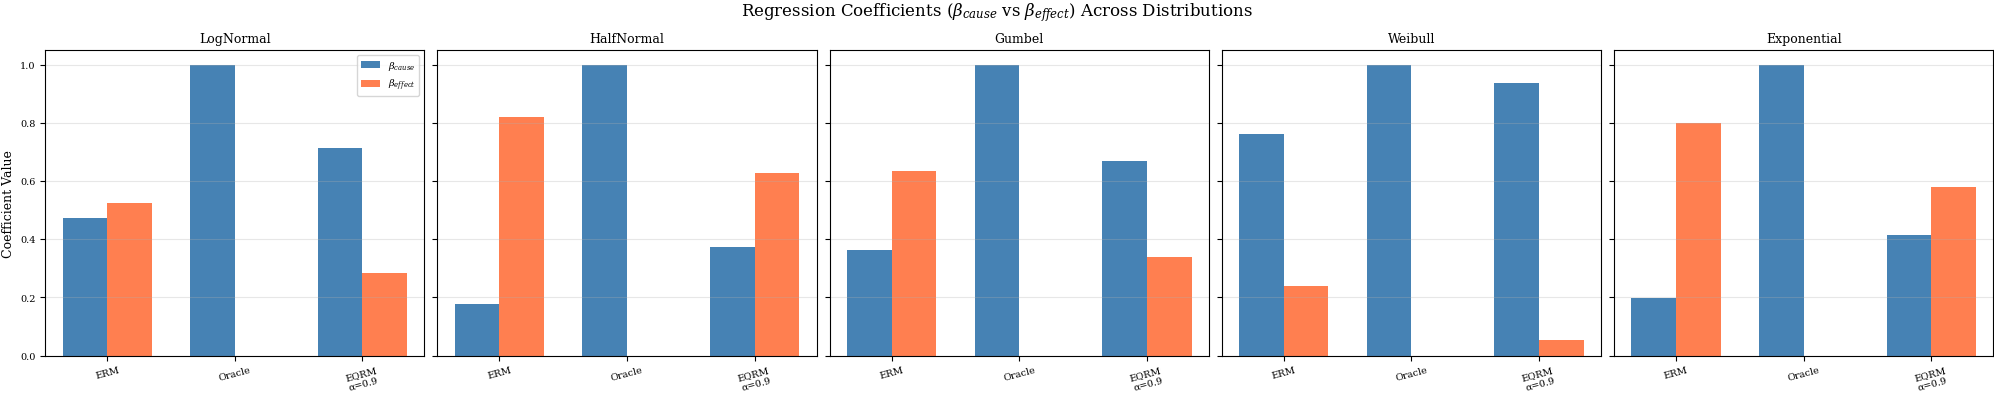

In [17]:
fig, axes = plt.subplots(1, len(dist_results), figsize=(4 * len(dist_results), 4), sharey=True)

for idx, (dist_name, models) in enumerate(dist_results.items()):
    ax = axes[idx]
    m_names = list(models.keys())
    b_cause = [models[m]["w"][0] for m in m_names]
    b_effect = [models[m]["w"][1] for m in m_names]
    
    x = np.arange(len(m_names))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, b_cause, width, label=r'$\beta_{cause}$', color='steelblue')
    bars2 = ax.bar(x + width/2, b_effect, width, label=r'$\beta_{effect}$', color='coral')
    
    ax.set_title(dist_name)
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace("EQRM_a=", "EQRM\nα=") for n in m_names], fontsize=7, rotation=15)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.grid(True, axis='y', alpha=0.3)
    
    if idx == 0:
        ax.set_ylabel('Coefficient Value')
        ax.legend(fontsize=7)

plt.suptitle(r'Regression Coefficients ($\beta_{cause}$ vs $\beta_{effect}$) Across Distributions', fontsize=12)
# plt.tight_layout()  # Using constrained layout instead
plt.savefig(os.path.join(FIGS_DIR, "coefficients_across_distributions.pdf"))
plt.show()

### 10.1. Quantile Performance & Risk Distributions — Across Environment Distributions

For each environment distribution variant, we evaluate quantile performance using `plotting.plot_quantile_performance()` 
and visualize the per-environment risk distributions using kernel density estimation.


--- LogNormal ---
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75


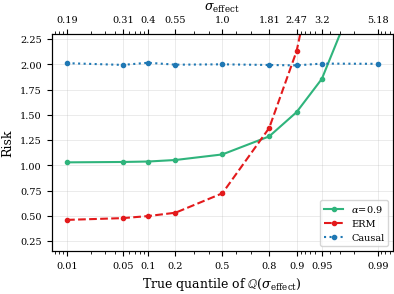

/tmp/ipykernel_1857040/864316410.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


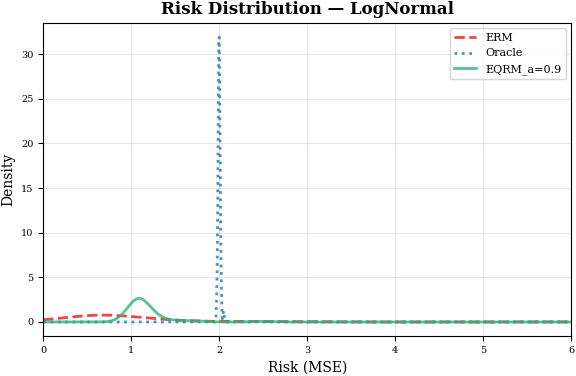


--- HalfNormal ---
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.25


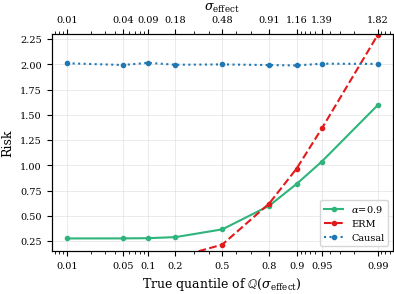

/tmp/ipykernel_1857040/864316410.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


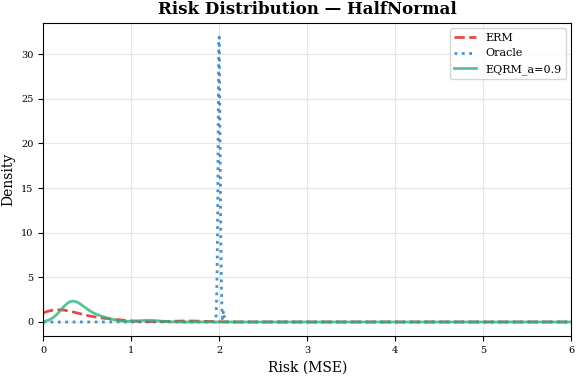


--- Gumbel ---
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.55


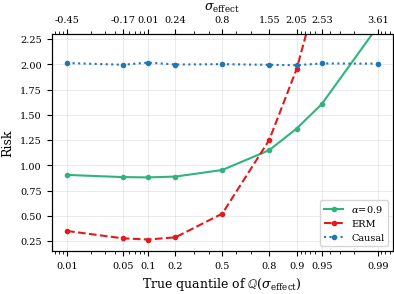

/tmp/ipykernel_1857040/864316410.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


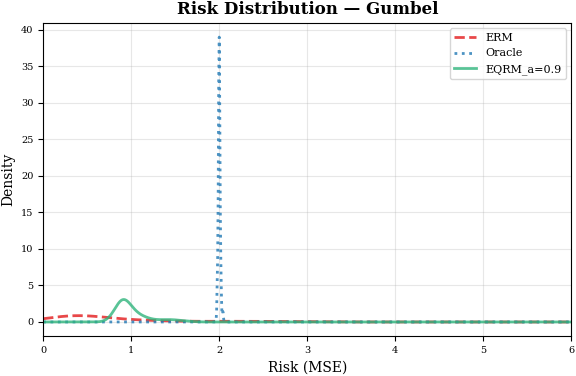


--- Weibull ---
Analytical OLS results
X1:MSE=1.33;	X2:MSE=1.36


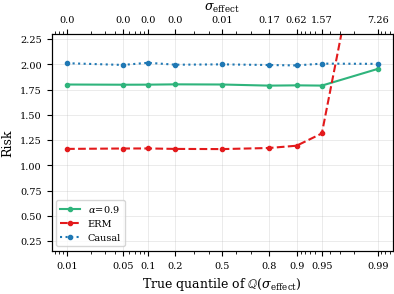

/tmp/ipykernel_1857040/864316410.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


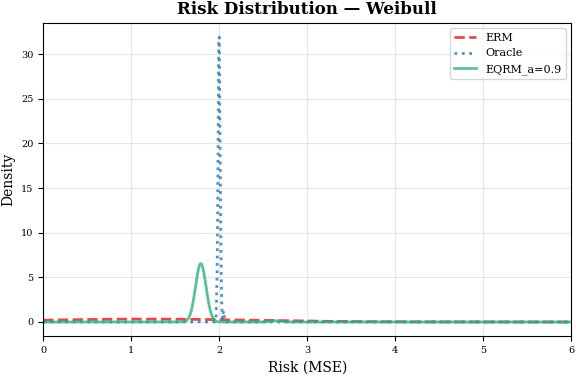


--- Exponential ---
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.28


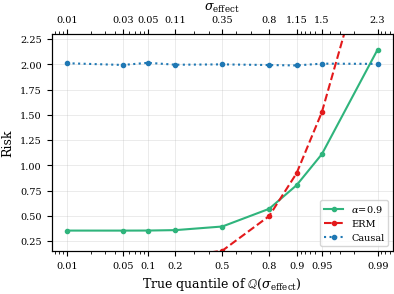

/tmp/ipykernel_1857040/864316410.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


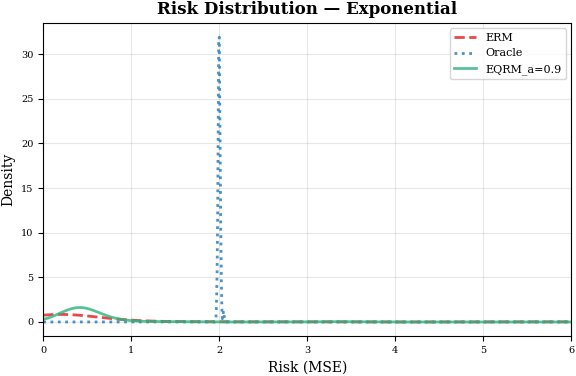

In [18]:
# ── Quantile Performance & Risk Distribution for each distribution variant ──
import torch as _torch

qs_qp = [0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 0.9, 0.95, 0.99]

for dist_name, DatasetClass in dist_variants.items():
    print(f'\n--- {dist_name} ---')
    utils.set_seed(SEED)
    ds_qp = DatasetClass(dim_inv=DIM_INV, dim_spu=DIM_SPU, n_envs=N_ENVS)
    
    # Re-train models for this distribution
    envs_r_qp = build_envs(ds_qp, N_SAMPLES, 'train')
    envs_o_qp = build_envs(ds_qp, N_SAMPLES, 'test')
    
    models_qp = {}
    utils.set_seed(SEED + 1000)
    erm_qp = algorithms.ERM(in_features, 1, 'regression')
    erm_qp.fit(envs_r_qp, N_ITERATIONS)
    models_qp['ERM'] = erm_qp
    
    utils.set_seed(SEED + 1000)
    orc_qp = algorithms.ERM(in_features, 1, 'regression')
    orc_qp.fit(envs_o_qp, N_ITERATIONS)
    models_qp['Oracle'] = orc_qp
    
    utils.set_seed(SEED + 1000)
    eqrm_qp = algorithms.EQRM(in_features, 1, 'regression')
    eqrm_qp.hparams['alpha'] = ALPHA_COMPARE
    eqrm_qp.fit(envs_r_qp, N_ITERATIONS)
    models_qp[f'EQRM_a={ALPHA_COMPARE}'] = eqrm_qp
    
    # ── Quantile Performance ──
    table_qp = {dist_name: {}}
    for name, model in models_qp.items():
        table_qp[dist_name][name] = {}
        for q in qs_qp:
            inputs, outputs, sdv = ds_qp.sample(n=N_SAMPLES, env=f'q={q}')
            risk = utils.compute_error(model, inputs, outputs)
            table_qp[dist_name][name][f'q={q}_s={round(sdv.item(), 2)}'] = {'mean': risk}
    
    plotting.plot_quantile_performance(table_qp, savedir=FIGS_DIR, fname=f'{dist_name}_quantile_perf')
    plt.show()
    
    # ── Risk Distribution ──
    xlim_max = 6
    xs = np.linspace(0, xlim_max, 1000)
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    
    for name, model in models_qp.items():
        if name == 'Oracle':
            per_env_risks = [utils.compute_error(model, *env) for env in envs_o_qp['validation']['envs']]
        else:
            per_env_risks = [utils.compute_error(model, *env) for env in envs_r_qp['validation']['envs']]
        
        style = model_styles.get(name, {'color': 'gray', 'linestyle': '-'})
        kde = utils.KernelDensityEstimator(_torch.tensor(per_env_risks))
        with _torch.no_grad():
            p_xs = kde(_torch.from_numpy(xs)).numpy()
        ax.plot(xs, p_xs, label=name, color=style['color'],
                linestyle=style['linestyle'], linewidth=2, alpha=0.8)
    
    ax.set_title(f'Risk Distribution — {dist_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Risk (MSE)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_xlim(0, xlim_max)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS_DIR, f'{dist_name}_risk_dist.pdf'), bbox_inches='tight')
    plt.show()


## 11. Sensitivity to Number of Environments

In [19]:
n_envs_sweep = [5, 10, 20, 50, 100, 1000]
alpha_fixed = 0.9
sensitivity_results = {n: {} for n in n_envs_sweep}

for n_e in n_envs_sweep:
    print(f"\nN_ENVS = {n_e}")
    utils.set_seed(SEED)
    ds = datasets.Example2(dim_inv=DIM_INV, dim_spu=DIM_SPU, n_envs=n_e)
    
    envs_r = build_envs(ds, N_SAMPLES, "train")
    envs_o = build_envs(ds, N_SAMPLES, "test")
    
    # ERM
    utils.set_seed(SEED + 1000)
    erm_s = algorithms.ERM(in_features, 1, "regression")
    erm_s.fit(envs_r, N_ITERATIONS)
    
    # Oracle
    utils.set_seed(SEED + 1000)
    orc_s = algorithms.ERM(in_features, 1, "regression")
    orc_s.fit(envs_o, N_ITERATIONS)
    
    # EQRM
    utils.set_seed(SEED + 1000)
    eqrm_s = algorithms.EQRM(in_features, 1, "regression")
    eqrm_s.hparams["alpha"] = alpha_fixed
    eqrm_s.fit(envs_r, N_ITERATIONS)
    
    for name, alg, envs_u in [("ERM", erm_s, envs_r), ("Oracle", orc_s, envs_o), (f"EQRM", eqrm_s, envs_r)]:
        risks = [utils.compute_error(alg, *env) for env in envs_u["validation"]["envs"]]
        w = alg.network.weight.data.flatten().tolist()
        sensitivity_results[n_e][name] = {
            "avg_risk": np.mean(risks),
            "max_risk": np.max(risks),
            "beta_effect": round(w[1], 3) if len(w) > 1 else None
        }
        print(f"  {name:12s} | avg={np.mean(risks):.4f} | β_effect={w[1]:.3f}")


N_ENVS = 5
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.89
  ERM          | avg=1.0888 | β_effect=0.452
  Oracle       | avg=2.0074 | β_effect=-0.001
  EQRM         | avg=1.4177 | β_effect=0.181

N_ENVS = 10
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75
  ERM          | avg=0.9580 | β_effect=0.525
  Oracle       | avg=1.9944 | β_effect=-0.000
  EQRM         | avg=1.2555 | β_effect=0.244

N_ENVS = 20
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.65
  ERM          | avg=0.8410 | β_effect=0.580
  Oracle       | avg=1.9993 | β_effect=0.001
  EQRM         | avg=1.0748 | β_effect=0.320

N_ENVS = 50
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75
  ERM          | avg=0.9456 | β_effect=0.526
  Oracle       | avg=1.9994 | β_effect=0.000
  EQRM         | avg=1.1663 | β_effect=0.285

N_ENVS = 100
Analytical OLS results
X1:MSE=1.33;	X2:MSE=1.02
  ERM          | avg=1.2154 | β_effect=0.392
  Oracle       | avg=1.9979 | β_effect=-0.000
  EQRM         | avg=1.4421 | β_effect=0.181

N_ENVS = 1000
An

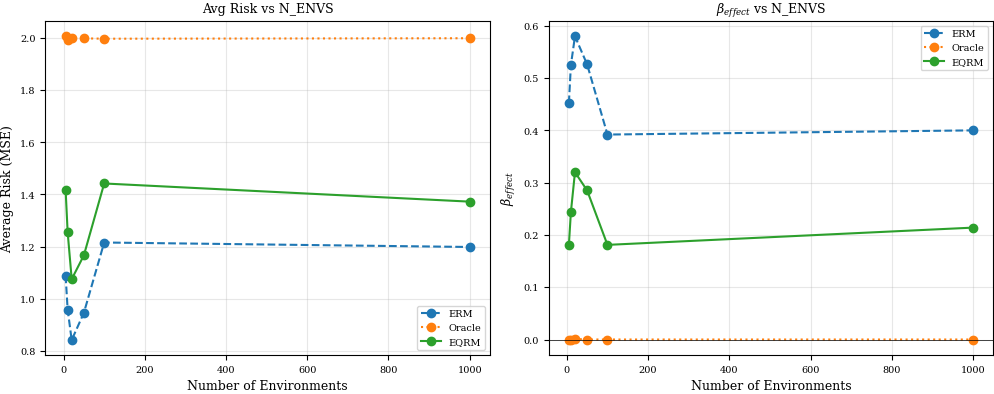

In [20]:
# Plot sensitivity results
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for m_name in ["ERM", "Oracle", "EQRM"]:
    avg_risks = [sensitivity_results[n][m_name]["avg_risk"] for n in n_envs_sweep]
    beta_effects = [sensitivity_results[n][m_name]["beta_effect"] for n in n_envs_sweep]
    
    style = "--" if m_name == "ERM" else (":" if m_name == "Oracle" else "-")
    marker = 'o'
    
    axes[0].plot(n_envs_sweep, avg_risks, label=m_name, linestyle=style, marker=marker)
    if all(b is not None for b in beta_effects):
        axes[1].plot(n_envs_sweep, beta_effects, label=m_name, linestyle=style, marker=marker)

axes[0].set_xlabel("Number of Environments")
axes[0].set_ylabel("Average Risk (MSE)")
axes[0].set_title("Avg Risk vs N_ENVS")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Number of Environments")
axes[1].set_ylabel(r"$\beta_{effect}$")
axes[1].set_title(r"$\beta_{effect}$ vs N_ENVS")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='black', linewidth=0.5, linestyle='-')

# plt.tight_layout()  # Using constrained layout instead
plt.savefig(os.path.join(FIGS_DIR, "sensitivity_n_envs.pdf"))
plt.show()

## 12. Experiment — Impact of Pure Non-Linearity

We evaluate models on purely non-linear causal mechanisms $y = f(x_1) + \epsilon$. 
We test different non-linear functions $f(x)$:
1. $f(x) = x$
2. $f(x) = x^3$
3. $f(x) = \tanh(2x)$
4. $f(x) = \text{sign}(x) \cdot |x|^{0.5}$ (Square root behavior)

Since our models are linear, we expect some approximation error, but we want to see if EQRM still maintains lower tail risk (MSE) in the most unstable environments.

In [21]:
class PurelyNonLinearDataset(datasets.Example2):
    def __init__(self, func_type="linear", **kwargs):
        super().__init__(**kwargs)
        self.func_type = func_type
    
    def f(self, x):
        if self.func_type == "linear": return x
        if self.func_type == "cubic": return x**3
        if self.func_type == "tanh": return torch.tanh(2.0 * x)
        if self.func_type == "sqrt": return torch.sign(x) * torch.sqrt(torch.abs(x))
        return x
    
    def sample(self, n=1000, env="E0", split="train"):
        is_quantile = "q=" in env
        if "test" in env or is_quantile:
            if is_quantile:
                q = torch.tensor(float(env[env.index("=") + 1:]), dtype=torch.float64)
                sdv = self.p_env.icdf(q)
            else:
                sdv = self.p_env.sample()
        else:
            sdv = self.envs[env]

        x1 = torch.randn(n, self.dim_inv) * self.x1_sdv
        y = self.f(x1) + torch.randn(n, self.dim_inv) * self.y_sdv
        x2 = y + torch.randn(n, self.dim_spu) * sdv

        if "E" in env and split == "test":
            x2 = x2[torch.randperm(len(x2))]

        inputs = torch.cat((x1, x2), -1)
        outputs = y.sum(1, keepdim=True)
        if is_quantile:
            return inputs, outputs, sdv
        return inputs, outputs

print("PurelyNonLinearDataset defined.")

PurelyNonLinearDataset defined.


### 11.1. Quantile Performance & Risk Distribution — Sensitivity to N_ENVS

For each value of N_ENVS tested, we evaluate quantile performance and plot risk distributions.


N_ENVS = 5
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.89


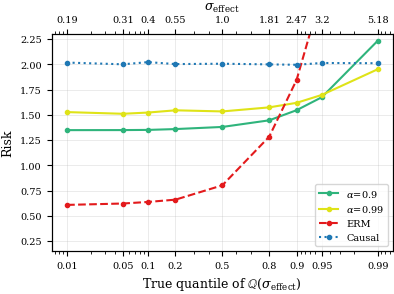

/tmp/ipykernel_1857040/353012594.py:70: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


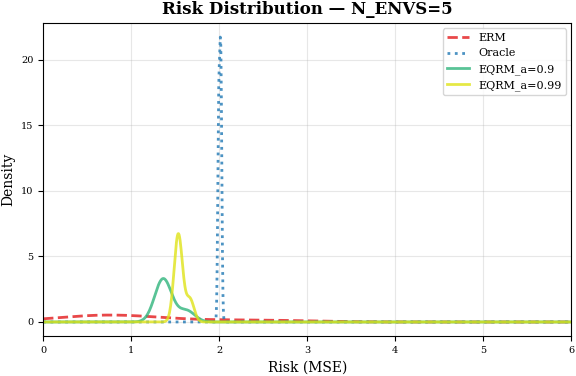


N_ENVS = 10
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75


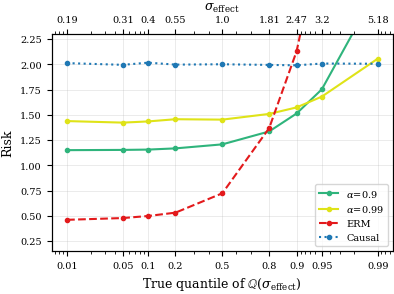

/tmp/ipykernel_1857040/353012594.py:70: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


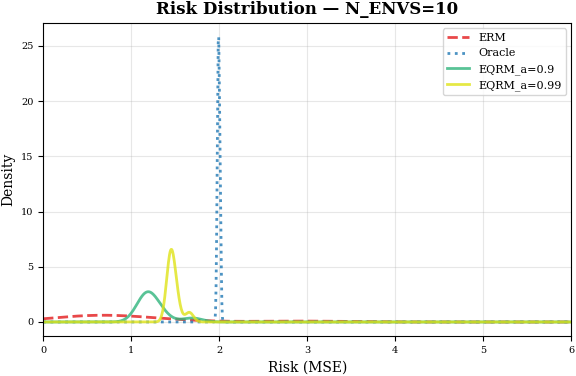


N_ENVS = 20
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.65


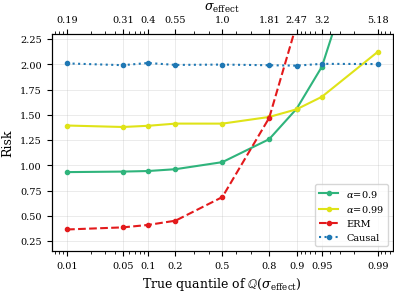

/tmp/ipykernel_1857040/353012594.py:70: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


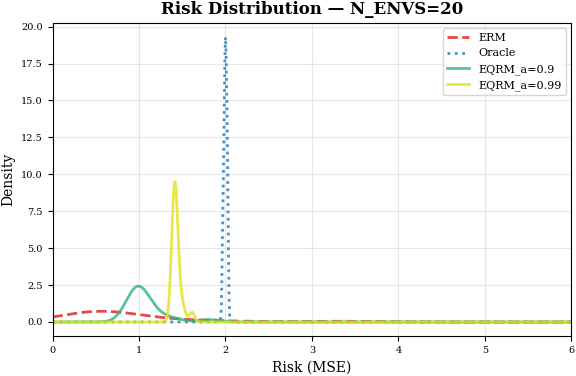


N_ENVS = 50
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75


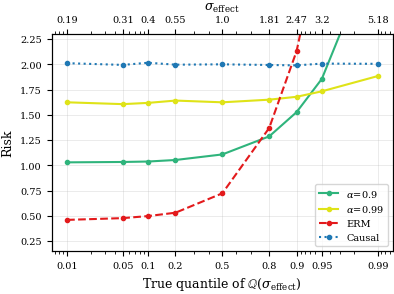

/tmp/ipykernel_1857040/353012594.py:70: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


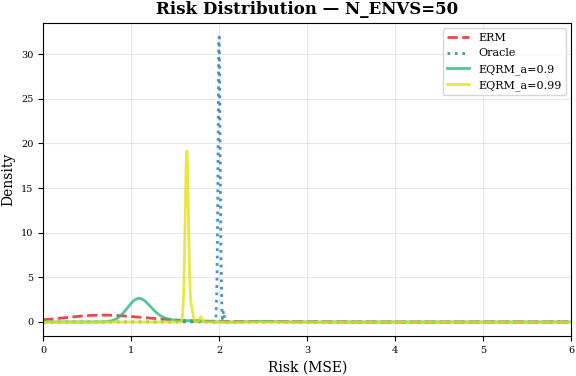


N_ENVS = 100
Analytical OLS results
X1:MSE=1.33;	X2:MSE=1.02


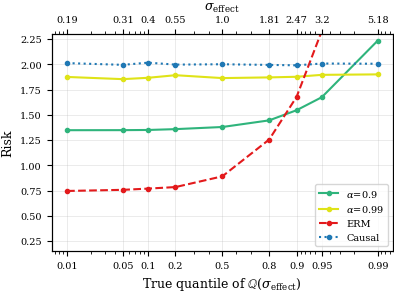

/tmp/ipykernel_1857040/353012594.py:70: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


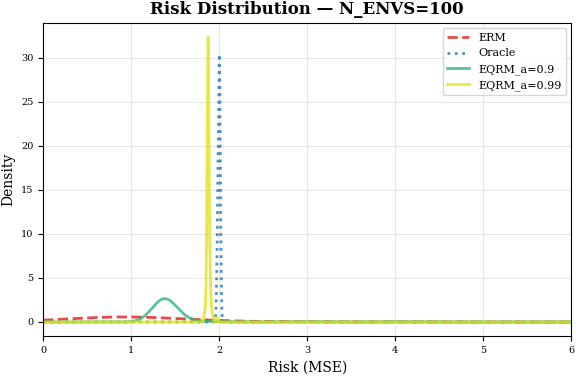

In [22]:
# ── Quantile Performance & Risk Distribution for sensitivity experiment ──
# This requires re-running the training loop for each N_ENVS value
import torch as _torch

qs_qp = [0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 0.9, 0.95, 0.99]
N_ENVS_VALUES = [5, 10, 20, 50, 100]

for n_e in N_ENVS_VALUES:
    print(f'\nN_ENVS = {n_e}')
    utils.set_seed(SEED)
    ds_ne = datasets.Example2(dim_inv=DIM_INV, dim_spu=DIM_SPU, n_envs=n_e)
    envs_r_ne = build_envs(ds_ne, N_SAMPLES, 'train')
    envs_o_ne = build_envs(ds_ne, N_SAMPLES, 'test')
    
    models_ne = {}
    utils.set_seed(SEED + 1000)
    erm_ne = algorithms.ERM(in_features, 1, 'regression')
    erm_ne.fit(envs_r_ne, N_ITERATIONS)
    models_ne['ERM'] = erm_ne
    
    utils.set_seed(SEED + 1000)
    orc_ne = algorithms.ERM(in_features, 1, 'regression')
    orc_ne.fit(envs_o_ne, N_ITERATIONS)
    models_ne['Oracle'] = orc_ne
    
    for alpha in [0.9, 0.99]:
        utils.set_seed(SEED + 1000)
        eqrm_ne = algorithms.EQRM(in_features, 1, 'regression')
        eqrm_ne.hparams['alpha'] = alpha
        eqrm_ne.fit(envs_r_ne, N_ITERATIONS)
        models_ne[f'EQRM_a={alpha}'] = eqrm_ne
    
    # ── Quantile Performance ──
    label = f'N_ENVS={n_e}'
    table_qp = {label: {}}
    for name, model in models_ne.items():
        table_qp[label][name] = {}
        for q in qs_qp:
            inputs, outputs, sdv = ds_ne.sample(n=N_SAMPLES, env=f'q={q}')
            risk = utils.compute_error(model, inputs, outputs)
            table_qp[label][name][f'q={q}_s={round(sdv.item(), 2)}'] = {'mean': risk}
    
    plotting.plot_quantile_performance(table_qp, savedir=FIGS_DIR, fname=f'nenvs_{n_e}_quantile_perf')
    plt.show()
    
    # ── Risk Distribution ──
    xlim_max = 6
    xs = np.linspace(0, xlim_max, 1000)
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    
    for name, model in models_ne.items():
        if name == 'Oracle':
            per_env_risks = [utils.compute_error(model, *env) for env in envs_o_ne['validation']['envs']]
        else:
            per_env_risks = [utils.compute_error(model, *env) for env in envs_r_ne['validation']['envs']]
        
        style = model_styles.get(name, {'color': 'gray', 'linestyle': '-'})
        kde = utils.KernelDensityEstimator(_torch.tensor(per_env_risks))
        with _torch.no_grad():
            p_xs = kde(_torch.from_numpy(xs)).numpy()
        ax.plot(xs, p_xs, label=name, color=style['color'],
                linestyle=style['linestyle'], linewidth=2, alpha=0.8)
    
    ax.set_title(f'Risk Distribution — N_ENVS={n_e}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Risk (MSE)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_xlim(0, xlim_max)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS_DIR, f'nenvs_{n_e}_risk_dist.pdf'), bbox_inches='tight')
    plt.show()


In [23]:
FUNC_TYPES = ['linear', 'cubic', 'tanh', 'sqrt']
exp_c_results = {}

print("EXPERIMENT C: Pure Non-linearity")
for ft in FUNC_TYPES:
    print(f"\nFunction: {ft}")
    utils.set_seed(SEED)
    ds = PurelyNonLinearDataset(func_type=ft, dim_inv=DIM_INV, dim_spu=DIM_SPU, n_envs=N_ENVS, verbose=False)
    
    envs_r = build_envs(ds, N_SAMPLES, "train")
    envs_o = build_envs(ds, N_SAMPLES, "test")
    
    results = {}
    # Train ERM
    utils.set_seed(SEED + 1000)
    erm_c = train_algorithm(algorithms.ERM, envs_r, DIM_INV + DIM_SPU, N_ITERATIONS)
    results["ERM"] = erm_c
    # Train Oracle
    utils.set_seed(SEED + 1000)
    orc_c = train_algorithm(algorithms.ERM, envs_o, DIM_INV + DIM_SPU, N_ITERATIONS)
    results["Oracle"] = orc_c
    # Train EQRM variants
    for alpha in [0.9, 0.99]:
        name = f"EQRM_a={alpha}"
        utils.set_seed(SEED + 1000)
        eqrm_c = algorithms.EQRM(DIM_INV + DIM_SPU, 1, "regression")
        eqrm_c.hparams["alpha"] = alpha
        eqrm_c.fit(envs_r, N_ITERATIONS)
        results[name] = eqrm_c
    
    # Evaluate max risks
    res_dict = {}
    for m_name, model in results.items():
        val_risks = [utils.compute_error(model, *env) for env in envs_r["validation"]["envs"]]
        res_dict[m_name] = {"max_risk": np.max(val_risks)}
    
    exp_c_results[ft] = res_dict
    print(f"  ERM   | max={res_dict['ERM']['max_risk']:.4f}")
    print(f"  EQRM  | max={res_dict['EQRM_a=0.99']['max_risk']:.4f}")

EXPERIMENT C: Pure Non-linearity

Function: linear
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75
  ERM   | max=5.5174
  EQRM  | max=1.7908

Function: cubic
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75
  ERM   | max=12.4788
  EQRM  | max=5.3284

Function: tanh
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75
  ERM   | max=5.7572
  EQRM  | max=1.8729

Function: sqrt
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75
  ERM   | max=5.6531
  EQRM  | max=1.8379


## 13. Experiment — Complexity: SCM Structure and Causal Features

We test a more complex Structural Causal Model (SCM):
1. $X \sim N(0, 1)$
2. $X_2 = X + N(0, 0.1), \quad X_3 = X + N(0, 0.1)$
3. $Y = X_2 + X_3 + N(0, 1)$
4. $X_4 = Y + N(0, \sigma_e^2)$

Features used for prediction: $[X_2, X_3, X_4]$. 
Here, $X_2$ and $X_3$ are causal parents of $Y$, and $X_4$ is a spurious effect.

In [24]:
class ComplexSCMDataset(datasets.Example2):
    def sample(self, n=1000, env="E0", split="train"):
        if "test" in env:
            if "q=" in env:
                q = torch.tensor(float(env[env.index("=") + 1:]), dtype=torch.float64)
                sdv = self.p_env.icdf(q)
            else:
                sdv = self.p_env.sample()
        else:
            sdv = self.envs[env]

        # Root variable X
        X = torch.randn(n, 1)
        
        # Causal ancestors of Y
        x1 = X + torch.randn(n, 1) * 0.1
        x2 = X + torch.randn(n, 1) * 0.1
        x3 = x2 + torch.randn(n, 1) * 0.1
        x4 = x3 + X + torch.randn(n, 1) * 0.1
        x5 = x4 + x2 + torch.randn(n, 1) * 0.1
        
        # Target Y
        y = x5 + torch.randn(n, 1) * self.y_sdv
        
        # Spurious effect and other descendant
        x6 = y + torch.randn(n, 1) * sdv
        x7 = x3 + torch.randn(n, 1) * 0.1

        if "E" in env and split == "test":
            # Shuffle the spurious feature to break its correlation with Y
            x6 = x6[torch.randperm(len(x6))]

        # Model gets X1 through X7 (skipping the root X)
        inputs = torch.cat((x1, x2, x3, x4, x5, x6, x7), -1)
        outputs = y.sum(1, keepdim=True)
        return inputs, outputs

print("ComplexSCMDataset defined.")

ComplexSCMDataset defined.


In [25]:
print("EXPERIMENT D1: Specific Complex SCM")
utils.set_seed(SEED)
ds_scm = ComplexSCMDataset(n_envs=N_ENVS)

envs_r = build_envs(ds_scm, N_SAMPLES, "train")
envs_o = build_envs(ds_scm, N_SAMPLES, "test")

in_feats = 7 # [X1, X2, X3, X4, X5, X6, X7]
scm_models = {}

# Train algorithms
for name, alg_class in [("ERM", algorithms.ERM), ("Oracle", algorithms.ERM)]:
    utils.set_seed(SEED + 1000)
    m = alg_class(in_feats, 1, "regression")
    # For Oracle, we use envs_o which has shuffled spurious features
    target_envs = envs_o if name == "Oracle" else envs_r
    m.fit(target_envs, N_ITERATIONS)
    scm_models[name] = m

for alpha in [0.9, 0.99]:
    name = f"EQRM_a={alpha}"
    utils.set_seed(SEED + 1000)
    m = algorithms.EQRM(in_feats, 1, "regression")
    m.hparams["alpha"] = alpha
    m.fit(envs_r, N_ITERATIONS)
    scm_models[name] = m

print("\nComplex SCM Results (Max Risk across environments):")
for name, model in scm_models.items():
    risks = [utils.compute_error(model, *env) for env in envs_r["validation"]["envs"]]
    print(f"  {name:20s} | max_risk = {np.max(risks):.4f}")

EXPERIMENT D1: Specific Complex SCM
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75

Complex SCM Results (Max Risk across environments):
  ERM                  | max_risk = 5.5613
  Oracle               | max_risk = 2.0343
  EQRM_a=0.9           | max_risk = 2.4977
  EQRM_a=0.99          | max_risk = 1.8178


In [26]:
DIM_CAUSAL_VALUES = [1, 2, 5, 10]
exp_causal_results = {}

print("EXPERIMENT D2: Varying Number of Causal Variables")
for d_inv in DIM_CAUSAL_VALUES:
    print(f"\nCausal dims: {d_inv}")
    utils.set_seed(SEED)
    # Using Example2 where we vary dim_inv (causal parents of Y)
    ds = datasets.Example2(dim_inv=d_inv, dim_spu=1, n_envs=N_ENVS, verbose=False)
    
    envs_r = build_envs(ds, N_SAMPLES, "train")
    envs_o = build_envs(ds, N_SAMPLES, "test")
    
    in_feats = envs_r["train"]["envs"][0][0].shape[1]  # get actual feature count from data
    results = {}
    # Train ERM
    utils.set_seed(SEED + 1000)
    erm_d = train_algorithm(algorithms.ERM, envs_r, in_feats, N_ITERATIONS)
    results["ERM"] = erm_d
    # Train Oracle
    utils.set_seed(SEED + 1000)
    orc_d = train_algorithm(algorithms.ERM, envs_o, in_feats, N_ITERATIONS)
    results["Oracle"] = orc_d
    # Train EQRM
    for alpha in [0.9, 0.99]:
        name = f"EQRM_a={alpha}"
        utils.set_seed(SEED + 1000)
        eqrm_d = algorithms.EQRM(in_feats, 1, "regression")
        eqrm_d.hparams["alpha"] = alpha
        eqrm_d.fit(envs_r, N_ITERATIONS)
        results[name] = eqrm_d
        
    res_dict = {}
    for m_name, model in results.items():
        val_risks = [utils.compute_error(model, *env) for env in envs_r["validation"]["envs"]]
        res_dict[m_name] = {"max_risk": np.max(val_risks)}
    
    exp_causal_results[d_inv] = res_dict
    print(f"  ERM   | max={res_dict['ERM']['max_risk']:.4f}")
    print(f"  EQRM  | max={res_dict['EQRM_a=0.99']['max_risk']:.4f}")

EXPERIMENT D2: Varying Number of Causal Variables

Causal dims: 1
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75
  ERM   | max=5.5174
  EQRM  | max=1.7908

Causal dims: 2
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75
  ERM   | max=11.0490
  EQRM  | max=3.8014

Causal dims: 5
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75
  ERM   | max=21.9966
  EQRM  | max=9.7322

Causal dims: 10
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75
  ERM   | max=34.4474
  EQRM  | max=19.8083


## 14. Visualization: Experiments C & D

/tmp/ipykernel_1857040/2620502776.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


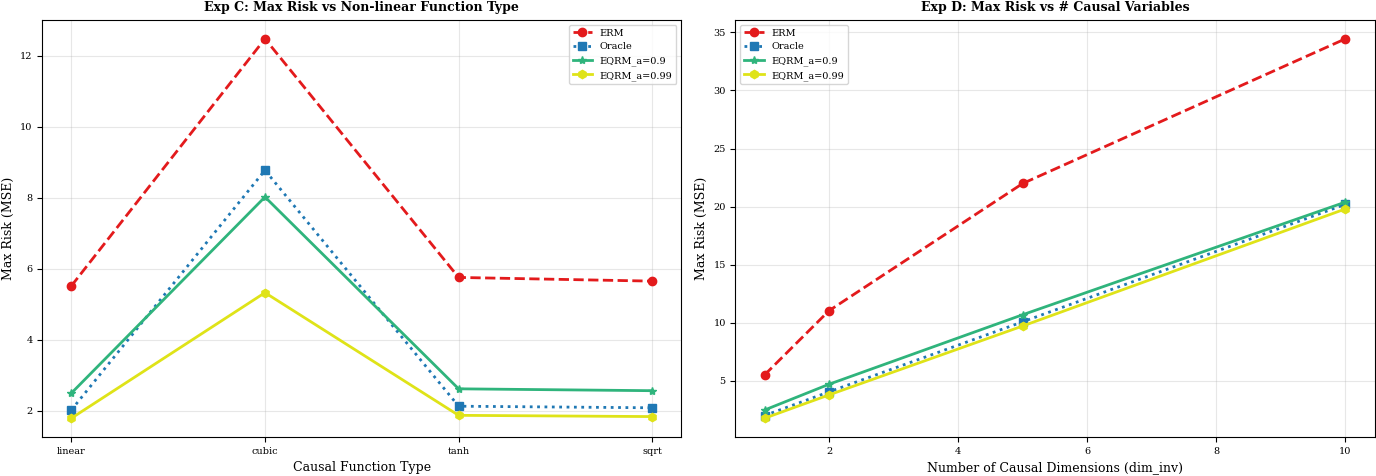

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Non-linearity (Exp C)
ax = axes[0]
for m_name in ["ERM", "Oracle", "EQRM_a=0.9", "EQRM_a=0.99"]:
    risks = [exp_c_results[ft][m_name]["max_risk"] for ft in FUNC_TYPES]
    ax.plot(FUNC_TYPES, risks, label=m_name, **model_styles[m_name], linewidth=2)
ax.set_title("Exp C: Max Risk vs Non-linear Function Type", fontweight='bold')
ax.set_xlabel("Causal Function Type")
ax.set_ylabel("Max Risk (MSE)")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Causal Complexity (Exp D2)
ax = axes[1]
for m_name in ["ERM", "Oracle", "EQRM_a=0.9", "EQRM_a=0.99"]:
    risks = [exp_causal_results[d][m_name]["max_risk"] for d in DIM_CAUSAL_VALUES]
    ax.plot(DIM_CAUSAL_VALUES, risks, label=m_name, **model_styles[m_name], linewidth=2)
ax.set_title("Exp D: Max Risk vs # Causal Variables", fontweight='bold')
ax.set_xlabel("Number of Causal Dimensions (dim_inv)")
ax.set_ylabel("Max Risk (MSE)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 14.1. Quantile Performance & Risk Distribution — Experiments C & D

Quantile performance evaluation and risk distributions for the non-linearity (C) and complex SCM (D) experiments.

Experiment C: Non-Linearity

--- linear ---
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75


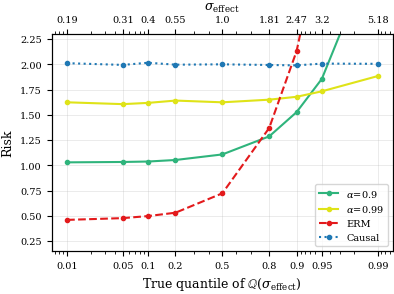

/tmp/ipykernel_1857040/1307161887.py:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


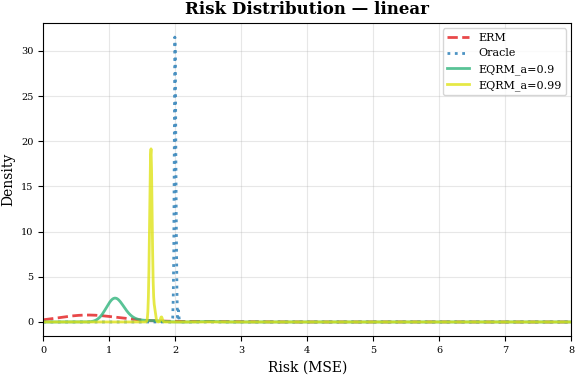


--- cubic ---
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75


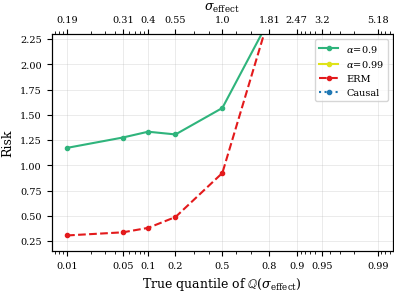

/tmp/ipykernel_1857040/1307161887.py:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


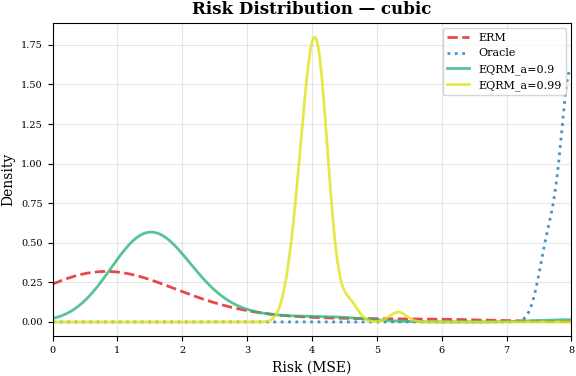


--- tanh ---
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75


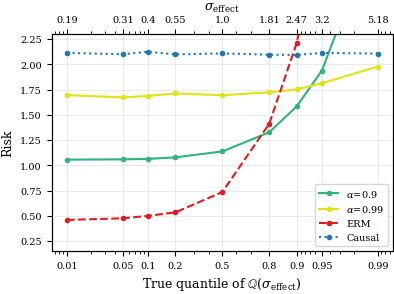

/tmp/ipykernel_1857040/1307161887.py:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


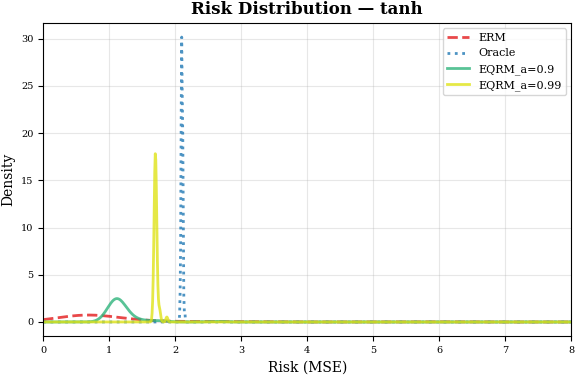


--- sqrt ---
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.75


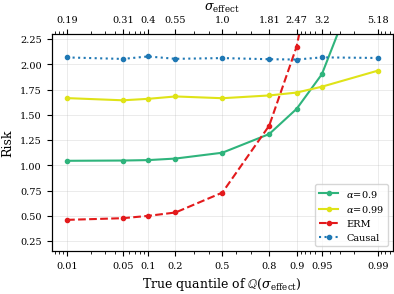

/tmp/ipykernel_1857040/1307161887.py:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


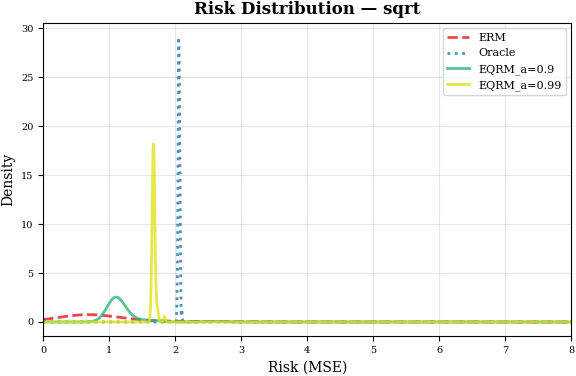

In [28]:
# ── Exp C: Quantile Performance & Risk Distribution for Non-Linearity ──
import torch as _torch

qs_qp = [0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 0.9, 0.95, 0.99]

print('Experiment C: Non-Linearity')
for ft in FUNC_TYPES:
    print(f'\n--- {ft} ---')
    utils.set_seed(SEED)
    ds_nl = PurelyNonLinearDataset(func_type=ft, dim_inv=DIM_INV, dim_spu=DIM_SPU, n_envs=N_ENVS, verbose=False)
    envs_r_nl = build_envs(ds_nl, N_SAMPLES, 'train')
    envs_o_nl = build_envs(ds_nl, N_SAMPLES, 'test')
    
    models_nl = {}
    utils.set_seed(SEED + 1000)
    erm_nl = train_algorithm(algorithms.ERM, envs_r_nl, DIM_INV + DIM_SPU, N_ITERATIONS)
    models_nl['ERM'] = erm_nl
    
    utils.set_seed(SEED + 1000)
    orc_nl = train_algorithm(algorithms.ERM, envs_o_nl, DIM_INV + DIM_SPU, N_ITERATIONS)
    models_nl['Oracle'] = orc_nl
    
    for alpha in [0.9, 0.99]:
        utils.set_seed(SEED + 1000)
        eqrm_nl = algorithms.EQRM(DIM_INV + DIM_SPU, 1, 'regression')
        eqrm_nl.hparams['alpha'] = alpha
        eqrm_nl.fit(envs_r_nl, N_ITERATIONS)
        models_nl[f'EQRM_a={alpha}'] = eqrm_nl
    
    # ── Quantile Performance ──
    label = f'NL_{ft}'
    table_qp = {label: {}}
    for name, model in models_nl.items():
        table_qp[label][name] = {}
        for q in qs_qp:
            inputs, outputs, sdv = ds_nl.sample(n=N_SAMPLES, env=f'q={q}')
            risk = utils.compute_error(model, inputs, outputs)
            table_qp[label][name][f'q={q}_s={round(sdv.item(), 2)}'] = {'mean': risk}
    
    plotting.plot_quantile_performance(table_qp, savedir=FIGS_DIR, fname=f'{ft}_quantile_perf')
    plt.show()
    
    # ── Risk Distribution ──
    xlim_max = 8
    xs = np.linspace(0, xlim_max, 1000)
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    
    for name, model in models_nl.items():
        if name == 'Oracle':
            per_env_risks = [utils.compute_error(model, *env) for env in envs_o_nl['validation']['envs']]
        else:
            per_env_risks = [utils.compute_error(model, *env) for env in envs_r_nl['validation']['envs']]
        
        style = model_styles.get(name, {'color': 'gray', 'linestyle': '-'})
        kde = utils.KernelDensityEstimator(_torch.tensor(per_env_risks))
        with _torch.no_grad():
            p_xs = kde(_torch.from_numpy(xs)).numpy()
        ax.plot(xs, p_xs, label=name, color=style['color'],
                linestyle=style['linestyle'], linewidth=2, alpha=0.8)
    
    ax.set_title(f'Risk Distribution — {ft}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Risk (MSE)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_xlim(0, xlim_max)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS_DIR, f'{ft}_risk_dist.pdf'), bbox_inches='tight')
    plt.show()
